# **OTT Feature Health Analysis**
# **AI Powered OTT Feature Graveyard Detector**

# Dataset Overview
# This dataset simulates OTT platform feature usage data
# from platforms like Netflix, Prime Video, and Spotify.
#
# The analysis focuses on:
# - identifying healthy features
# - detecting declining features
# - measuring retention
# - understanding churn behavior
# - evaluating feature engagement

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv("/content/feature_usage_dataset.csv")

In [12]:
df.head()

,user_id,feature_name,device_type,subscription_type,country,age_group,session_id,clicks,session_time_seconds,feature_used,reused_feature,retention_7d,retention_30d,churn_flag,feature_rating,engagement_score,watch_time_minutes,content_consumed_count,timestamp,feature_health
0,U001647,AI Recommendations,mobile,premium,US,55+,S00000001,8,478.0,1,1,1,1,0,2.0,0.457,4.6,1,2024-11-04 07:36:00,At Risk
1,U003277,Mini Preview Clips,mobile,basic,AU,25-34,S00000002,7,25.0,1,1,1,0,1,2.0,0.512,8.1,3,2024-08-06 23:07:00,At Risk
2,U003600,Downloads,desktop,basic,MX,25-34,S00000003,4,239.0,1,1,0,1,0,4.0,0.177,1.2,2,2024-09-26 18:30:00,Healthy
3,U008466,AI Recommendations,mobile,free,FR,45-54,S00000004,5,224.0,0,0,1,1,0,4.0,0.498,31.3,1,2025-02-23 20:05:00,At Risk
4,U006149,Watch Party,smart_tv,basic,IN,25-34,S00000005,4,333.0,0,0,0,0,0,2.0,0.186,3.2,2,2025-01-01 18:20:00,Dead


In [13]:

print("=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

FEATURE ANALYSIS

Dataset Shape:
(50000, 20)

Columns:
Index(['user_id', 'feature_name', 'device_type', 'subscription_type',
       'country', 'age_group', 'session_id', 'clicks', 'session_time_seconds',
       'feature_used', 'reused_feature', 'retention_7d', 'retention_30d',
       'churn_flag', 'feature_rating', 'engagement_score',
       'watch_time_minutes', 'content_consumed_count', 'timestamp',
       'feature_health'],
      dtype='object')


In [14]:
print("\n")
print("=" * 60)
print("FEATURE ADOPTION ANALYSIS")
print("=" * 60)

adoption_analysis = (

    df.groupby("feature_name")[
        "feature_used"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(adoption_analysis)




FEATURE ADOPTION ANALYSIS
feature_name
Downloads             0.847745
AI Recommendations    0.703246
Watchlist             0.652341
Mini Preview Clips    0.546871
Watch Party           0.113664
Name: feature_used, dtype: float64


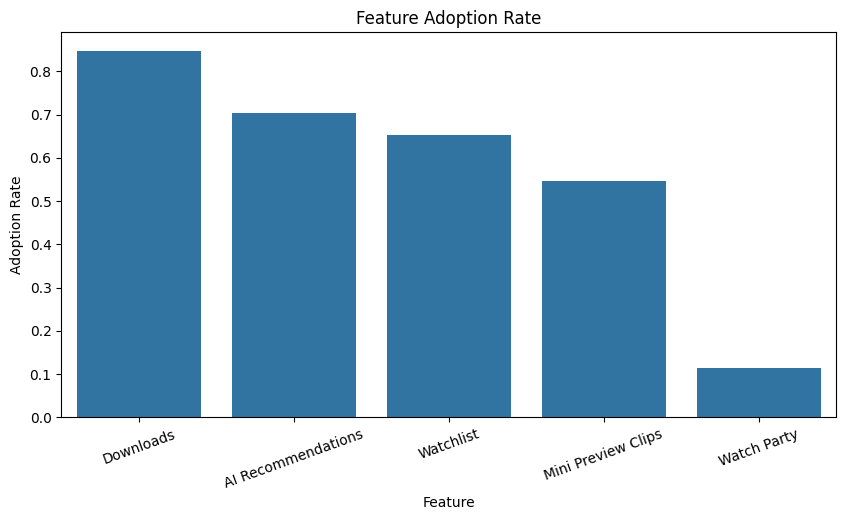

In [15]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=adoption_analysis.index,
    y=adoption_analysis.values
)

plt.title("Feature Adoption Rate")
plt.xlabel("Feature")
plt.ylabel("Adoption Rate")

plt.xticks(rotation=20)

plt.show()

In [37]:
print("=" * 60)
print("BUSINESS INSIGHT")
print("=" * 60)

top_feature = adoption_analysis.idxmax()
lowest_feature = adoption_analysis.idxmin()

print(f"""
1. {top_feature} has the highest adoption rate,
   indicating strong product-market fit.

2. {lowest_feature} has the lowest adoption rate,
   suggesting poor feature discoverability
   or weak user interest.

3. Highly adopted features contribute more
   to user retention and engagement.
""")

BUSINESS INSIGHT

1. Downloads has the highest adoption rate,
   indicating strong product-market fit.

2. Watch Party has the lowest adoption rate,
   suggesting poor feature discoverability
   or weak user interest.

3. Highly adopted features contribute more
   to user retention and engagement.



# ENGAGEMENT ANALYSIS

In [16]:
print("ENGAGEMENT ANALYSIS")
print("=" * 60)

engagement_analysis = (

    df.groupby("feature_name")[
        "engagement_score"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(engagement_analysis)

ENGAGEMENT ANALYSIS
feature_name
AI Recommendations    0.347817
Mini Preview Clips    0.326829
Downloads             0.324586
Watch Party           0.300755
Watchlist             0.300679
Name: engagement_score, dtype: float64


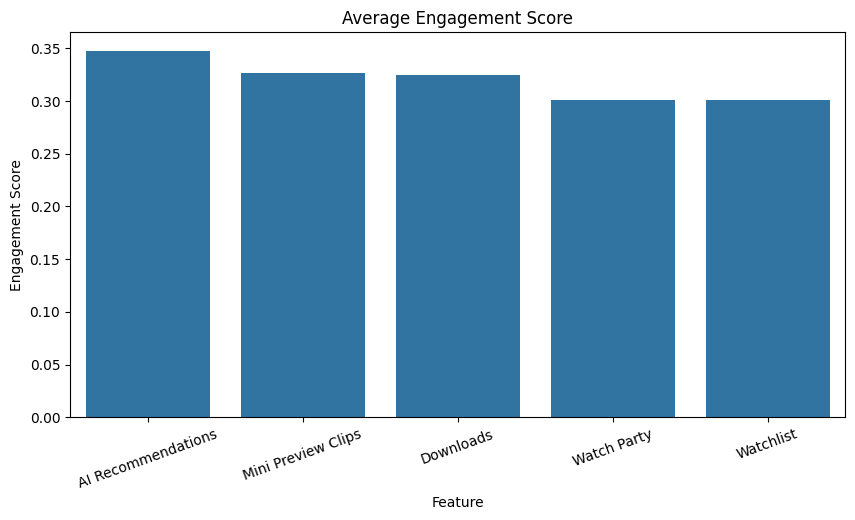

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=engagement_analysis.index,
    y=engagement_analysis.values
)

plt.title("Average Engagement Score")
plt.xlabel("Feature")
plt.ylabel("Engagement Score")

plt.xticks(rotation=20)

plt.show()

In [38]:
print("=" * 60)
print("ENGAGEMENT INSIGHT")
print("=" * 60)

best_engagement = engagement_analysis.idxmax()
worst_engagement = engagement_analysis.idxmin()

print(f"""
1. {best_engagement} generates the highest engagement,
   meaning users spend more time interacting with it.

2. {worst_engagement} shows weak engagement,
   indicating feature abandonment risk.

3. Engagement directly impacts OTT platform retention
   and subscription stickiness.
""")

ENGAGEMENT INSIGHT

1. AI Recommendations generates the highest engagement,
   meaning users spend more time interacting with it.

2. Watchlist shows weak engagement,
   indicating feature abandonment risk.

3. Engagement directly impacts OTT platform retention
   and subscription stickiness.



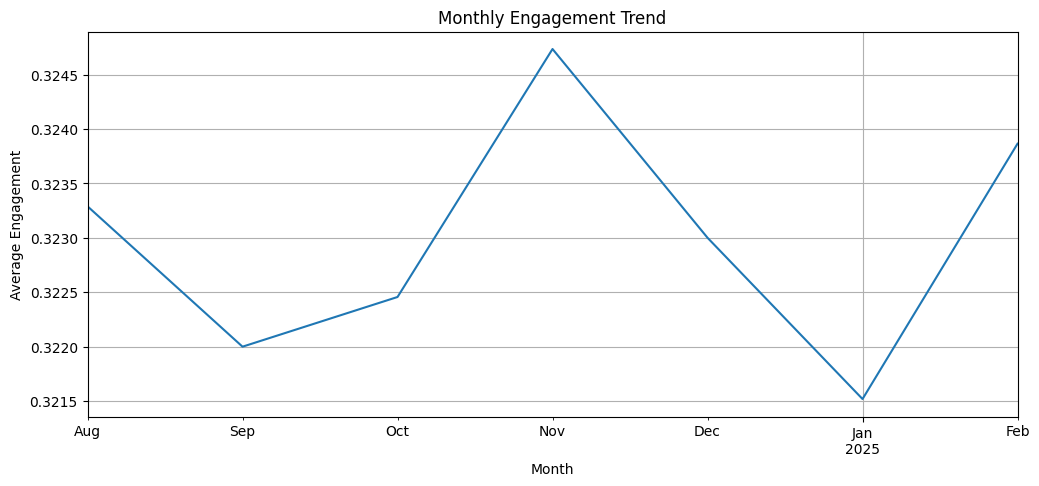

In [43]:
# =========================================================
# MONTHLY ENGAGEMENT TREND
# =========================================================

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df["month"] = df[
    "timestamp"
].dt.to_period("M")

monthly_engagement = (

    df.groupby("month")[
        "engagement_score"
    ]
    .mean()

)

plt.figure(figsize=(12, 5))

monthly_engagement.plot()

plt.title("Monthly Engagement Trend")

plt.xlabel("Month")

plt.ylabel("Average Engagement")

plt.grid(True)

plt.show()

# RETENTION ANALYSIS

In [19]:
retention_analysis = (

    df.groupby("feature_name")[
        ["retention_7d", "retention_30d"]
    ]
    .mean()

)

print(retention_analysis)

                    retention_7d  retention_30d
feature_name                                   
AI Recommendations      0.395914       0.278908
Downloads               0.716681       0.573345
Mini Preview Clips      0.298012       0.179694
Watch Party             0.150746       0.067513
Watchlist               0.603020       0.490529


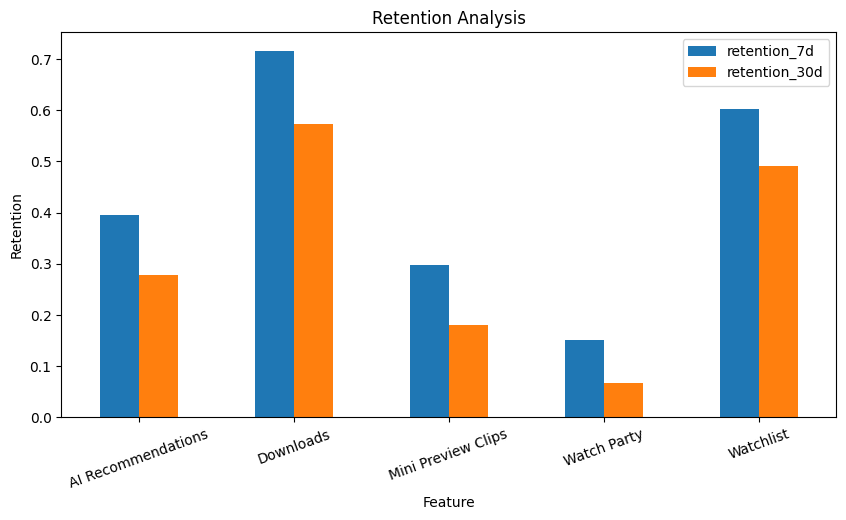

In [20]:
retention_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Retention Analysis")
plt.xlabel("Feature")
plt.ylabel("Retention")

plt.xticks(rotation=20)

plt.show()

In [39]:
print("=" * 60)
print("RETENTION INSIGHT")
print("=" * 60)

best_retention = retention_analysis[
    "retention_30d"
].idxmax()

lowest_retention = retention_analysis[
    "retention_30d"
].idxmin()

print(f"""
1. {best_retention} retains users effectively
   over the long term.

2. {lowest_retention} struggles to bring users back,
   indicating declining feature value.

3. Strong retention features increase
   overall platform loyalty.
""")

RETENTION INSIGHT

1. Downloads retains users effectively
   over the long term.

2. Watch Party struggles to bring users back,
   indicating declining feature value.

3. Strong retention features increase
   overall platform loyalty.



# CHURN ANALYSIS

In [21]:
churn_analysis = (

    df.groupby("feature_name")[
        "churn_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(churn_analysis)

feature_name
Watch Party           0.451431
Mini Preview Clips    0.302176
AI Recommendations    0.251211
Watchlist             0.151984
Downloads             0.099244
Name: churn_flag, dtype: float64


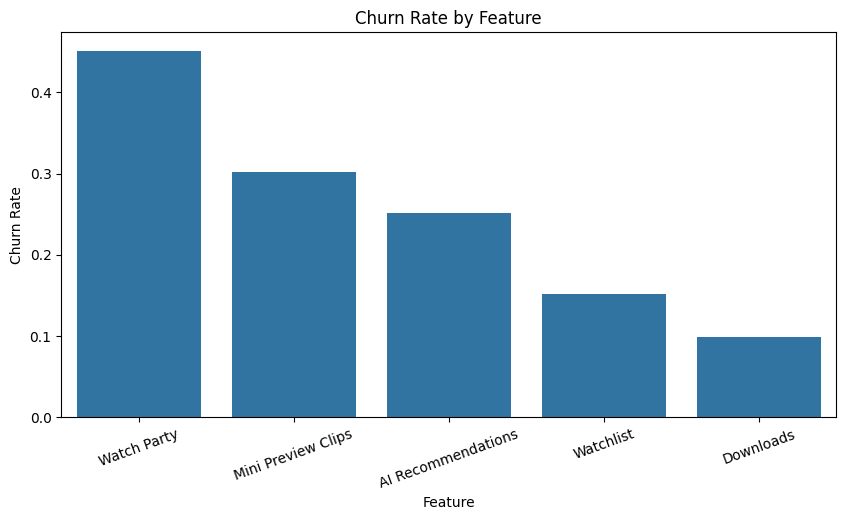

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=churn_analysis.index,
    y=churn_analysis.values
)

plt.title("Churn Rate by Feature")
plt.xlabel("Feature")
plt.ylabel("Churn Rate")

plt.xticks(rotation=20)

plt.show()

In [40]:
print("=" * 60)
print("CHURN INSIGHT")
print("=" * 60)

highest_churn = churn_analysis.idxmax()
lowest_churn = churn_analysis.idxmin()

print(f"""
1. {highest_churn} has the highest churn rate,
   meaning users disengage after interacting
   with the feature.

2. {lowest_churn} contributes positively
   to user retention.

3. High churn features may require:
   - UX redesign
   - performance improvements
   - better recommendations
""")

CHURN INSIGHT

1. Watch Party has the highest churn rate,
   meaning users disengage after interacting
   with the feature.

2. Downloads contributes positively
   to user retention.

3. High churn features may require:
   - UX redesign
   - performance improvements
   - better recommendations





CORRELATION HEATMAP


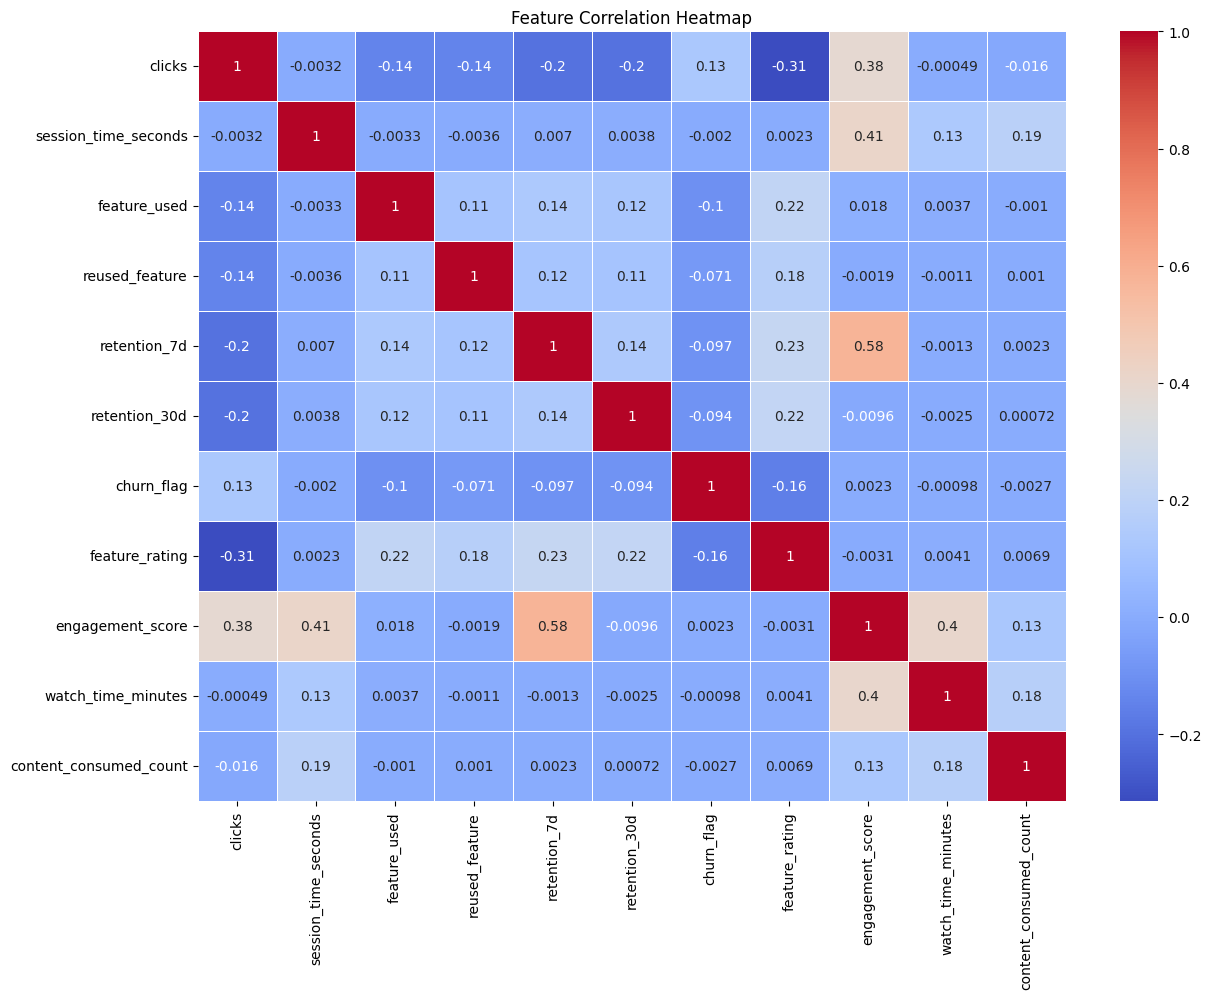

In [41]:
# =========================================================
# CORRELATION ANALYSIS
# =========================================================

print("\n")
print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

# numerical columns only
numerical_df = df.select_dtypes(
    include='number'
)

# correlation matrix
corr_matrix = numerical_df.corr()

# visualization
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

# FEATURE REUSE ANALYSIS

In [23]:
reuse_analysis = (

    df.groupby("feature_name")[
        "reused_feature"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(reuse_analysis)

feature_name
Downloads             0.750214
AI Recommendations    0.304587
Watchlist             0.301376
Mini Preview Clips    0.300295
Watch Party           0.294035
Name: reused_feature, dtype: float64


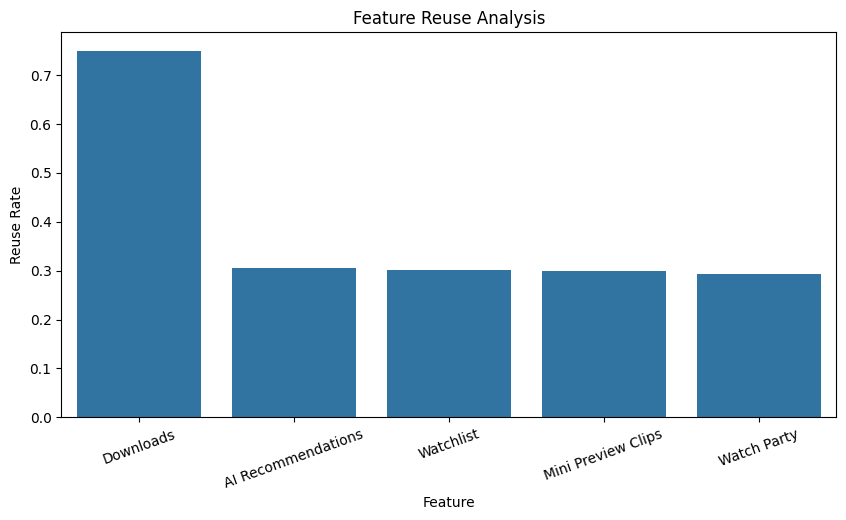

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=reuse_analysis.index,
    y=reuse_analysis.values
)

plt.title("Feature Reuse Analysis")
plt.xlabel("Feature")
plt.ylabel("Reuse Rate")

plt.xticks(rotation=20)

plt.show()


# WATCHTIME ANALYSIS


In [25]:
watch_time_analysis = (

    df.groupby("feature_name")[
        "watch_time_minutes"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(watch_time_analysis)

feature_name
Watchlist             13.912453
Mini Preview Clips    13.883909
AI Recommendations    13.841124
Downloads             13.816273
Watch Party           13.591216
Name: watch_time_minutes, dtype: float64


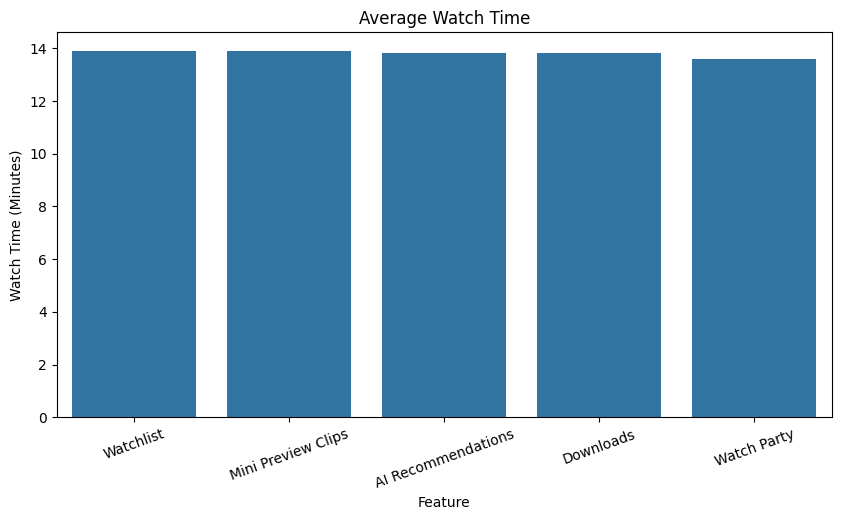

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=watch_time_analysis.index,
    y=watch_time_analysis.values
)

plt.title("Average Watch Time")
plt.xlabel("Feature")
plt.ylabel("Watch Time (Minutes)")

plt.xticks(rotation=20)

plt.show()

In [45]:
# =========================================================
# TOP PERFORMING FEATURES
# =========================================================

top_features = (

    df.groupby("feature_name")
    .agg({

        "engagement_score": "mean",

        "retention_30d": "mean",

        "churn_flag": "mean"

    })
    .sort_values(
        by="engagement_score",
        ascending=False
    )

)

print(top_features)

                    engagement_score  retention_30d  churn_flag
feature_name                                                   
AI Recommendations          0.347817       0.278908    0.251211
Mini Preview Clips          0.326829       0.179694    0.302176
Downloads                   0.324586       0.573345    0.099244
Watch Party                 0.300755       0.067513    0.451431
Watchlist                   0.300679       0.490529    0.151984


# CONTENT CONSUMPTION ANALYSIS


In [27]:
print("\n")
print("=" * 60)
print("CONTENT CONSUMPTION ANALYSIS")
print("=" * 60)

content_analysis = (

    df.groupby("feature_name")[
        "content_consumed_count"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(content_analysis)



CONTENT CONSUMPTION ANALYSIS
feature_name
Downloads             1.782106
Watchlist             1.750715
Mini Preview Clips    1.745232
Watch Party           1.743047
AI Recommendations    1.741521
Name: content_consumed_count, dtype: float64


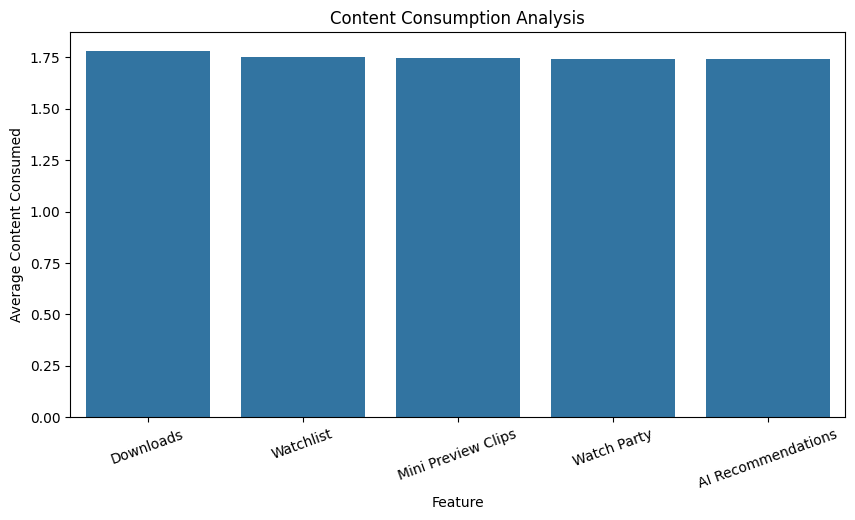

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=content_analysis.index,
    y=content_analysis.values
)

plt.title("Content Consumption Analysis")
plt.xlabel("Feature")
plt.ylabel("Average Content Consumed")

plt.xticks(rotation=20)

plt.show()

# FEATURE HEALTH DISTRIBUTION


In [29]:

health_distribution = (

    df["feature_health"]
    .value_counts()

)

print(health_distribution)


feature_health
Healthy    25208
At Risk    19830
Dead        4962
Name: count, dtype: int64


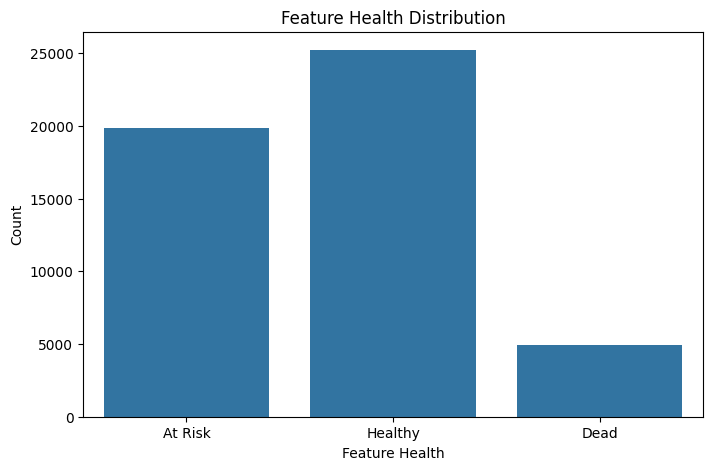

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="feature_health"
)

plt.title("Feature Health Distribution")
plt.xlabel("Feature Health")
plt.ylabel("Count")

plt.show()

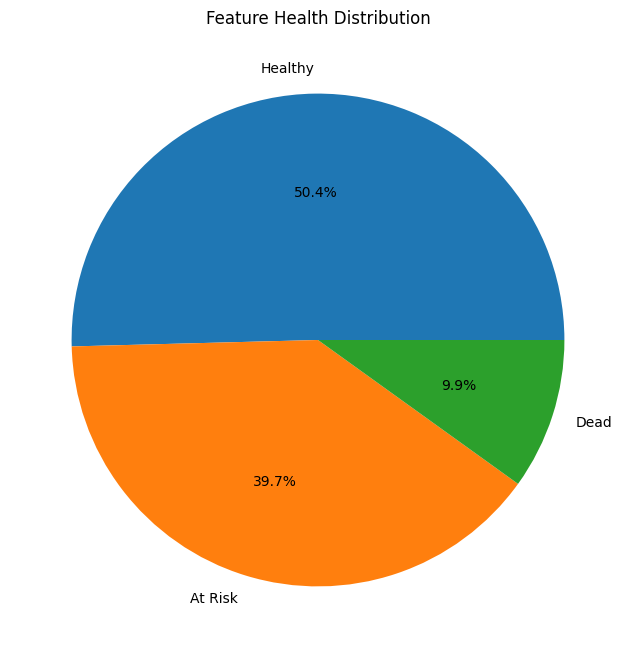

In [42]:
# =========================================================
# FEATURE HEALTH DISTRIBUTION
# =========================================================

health_counts = df[
    "feature_health"
].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    health_counts,
    labels=health_counts.index,
    autopct="%1.1f%%"
)

plt.title("Feature Health Distribution")

plt.show()

# DEVICE-WISE ENGAGEMENT


In [32]:
device_engagement = (

    df.groupby("device_type")[
        "engagement_score"
    ]
    .mean()
    .sort_values(ascending=False)

)
print(device_engagement)


device_type
tablet      0.327317
desktop     0.323715
smart_tv    0.322352
mobile      0.322164
Name: engagement_score, dtype: float64


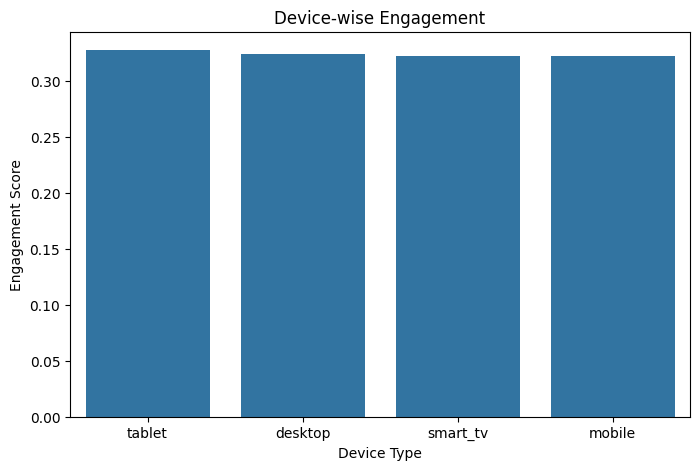

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=device_engagement.index,
    y=device_engagement.values
)

plt.title("Device-wise Engagement")
plt.xlabel("Device Type")
plt.ylabel("Engagement Score")

plt.show()

# SUBSCRIPTION-WISE RETENTION


In [34]:
print("\n")
print("=" * 60)
print("SUBSCRIPTION-WISE RETENTION")
print("=" * 60)

subscription_retention = (

    df.groupby("subscription_type")[
        "retention_30d"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(subscription_retention)



SUBSCRIPTION-WISE RETENTION
subscription_type
basic      0.407828
premium    0.369751
free       0.298763
Name: retention_30d, dtype: float64


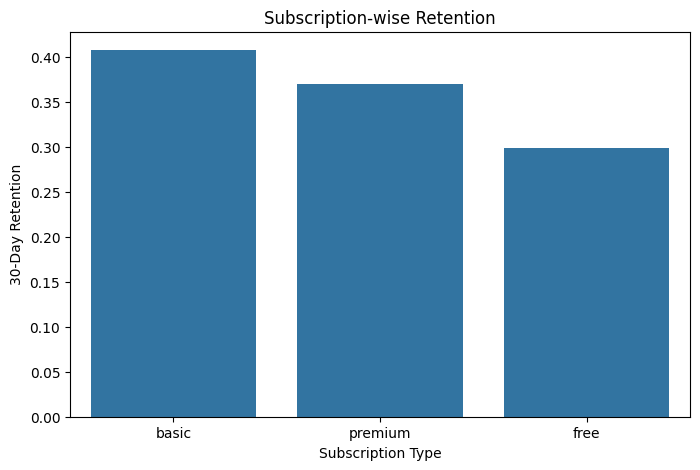

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=subscription_retention.index,
    y=subscription_retention.values
)

plt.title("Subscription-wise Retention")
plt.xlabel("Subscription Type")
plt.ylabel("30-Day Retention")

plt.show()

# TOP INSIGHTS

In [46]:
print("\n")
print("=" * 60)
print("TOP BUSINESS INSIGHTS")
print("=" * 60)

best_feature = engagement_analysis.idxmax()

worst_feature = engagement_analysis.idxmin()

highest_churn = churn_analysis.idxmax()

best_retention = retention_analysis[
    "retention_30d"
].idxmax()

print(f"\nBest Engaging Feature: {best_feature}")

print(f"Worst Performing Feature: {worst_feature}")

print(f"Highest Churn Feature: {highest_churn}")

print(f"Best Retention Feature: {best_retention}")




TOP BUSINESS INSIGHTS

Best Engaging Feature: AI Recommendations
Worst Performing Feature: Watchlist
Highest Churn Feature: Watch Party
Best Retention Feature: Downloads


# Feature Health vs Churn Visualization

/tmp/ipykernel_19120/499120413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


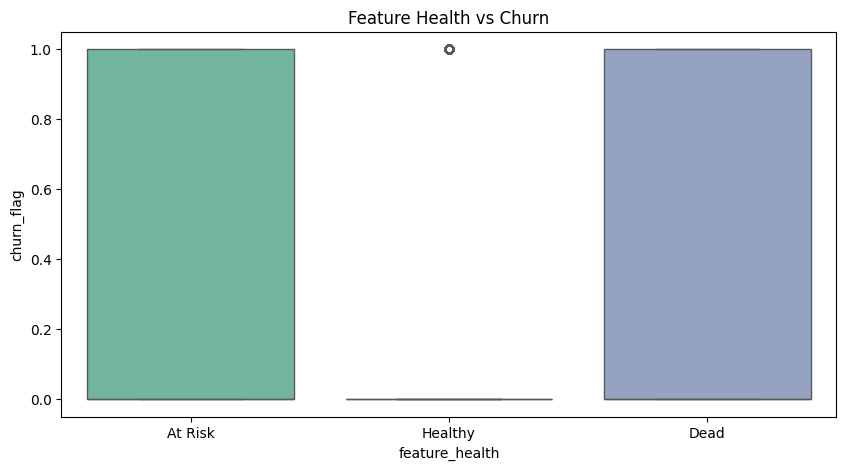

In [47]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="feature_health",
    y="churn_flag",
    palette="Set2"
)

plt.title("Feature Health vs Churn")

plt.show()

Shows:

dead features → high churn
healthy features → low churn

# Retention Heatmap

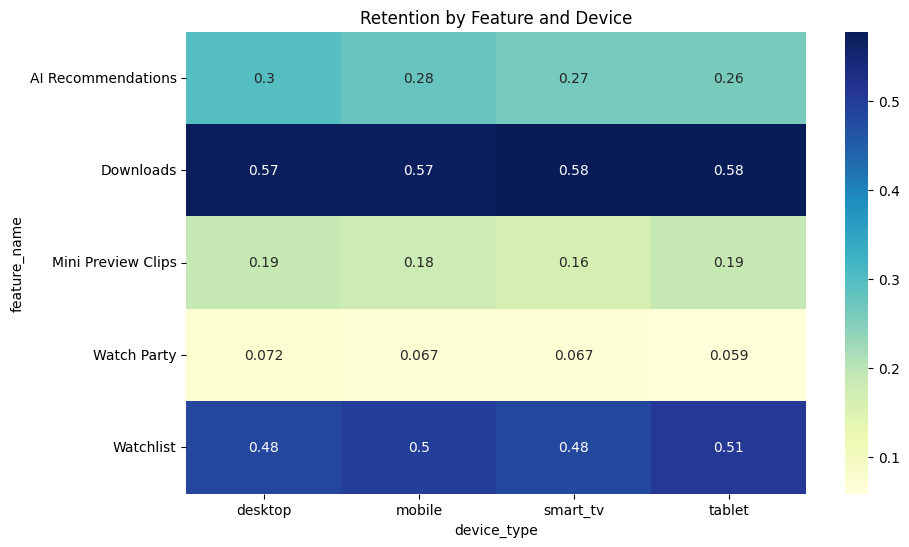

In [48]:
retention_heatmap = (

    df.pivot_table(
        values="retention_30d",
        index="feature_name",
        columns="device_type",
        aggfunc="mean"
    )

)

plt.figure(figsize=(10,6))

sns.heatmap(
    retention_heatmap,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Retention by Feature and Device")

plt.show()

# Engagement Distribution

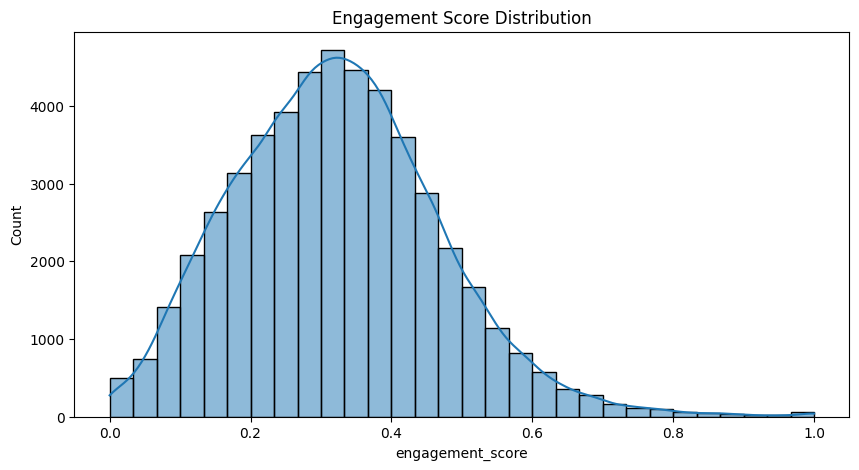

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["engagement_score"],
    bins=30,
    kde=True
)

plt.title("Engagement Score Distribution")

plt.show()

# Top Churn Features Table

In [50]:
top_churn = (

    df.groupby("feature_name")[
        "churn_flag"
    ]
    .mean()
    .sort_values(ascending=False)

)

print(top_churn)

feature_name
Watch Party           0.451431
Mini Preview Clips    0.302176
AI Recommendations    0.251211
Watchlist             0.151984
Downloads             0.099244
Name: churn_flag, dtype: float64



# Final Product Insights

# 1. Downloads is the strongest feature
#    with high engagement and retention.

# 2. AI Recommendations positively impact
#    platform stickiness and watch behavior.

# 3. Watch Party shows signs of feature decay
#    with low reuse and high churn.

# 4. Mini Preview Clips and Watchlist
#    are moderately adopted but require UX improvements.

# 5. Retention strongly correlates with engagement,
#    proving that highly engaging features
#    improve platform loyalty.